17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6905 - loss: 0.5724 - val_accuracy: 0.7836 - val_loss: 0.4752
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7944 - loss: 0.4502 - val_accuracy: 0.7596 - val_loss: 0.5142
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8065 - loss: 0.4240 - val_accuracy: 0.7738 - val_loss: 0.5272
RNN Accuracy: 0.7760

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7941 - loss: 0.4405 - val_accuracy: 0.8600 - val_loss: 0.3389
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8878 - loss: 0.2825 - val_accuracy: 0.8678 - val_loss: 0.3318
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9278 - loss: 0.1948 - val_accuracy: 0.8616 - val_loss: 0.3542
LSTM Accuracy: 0.8487

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7829 - loss: 0.4428 - val_accuracy: 0.8698 - val_loss: 0.3315
Epoch 2/3
313/313 ━━━━━━━

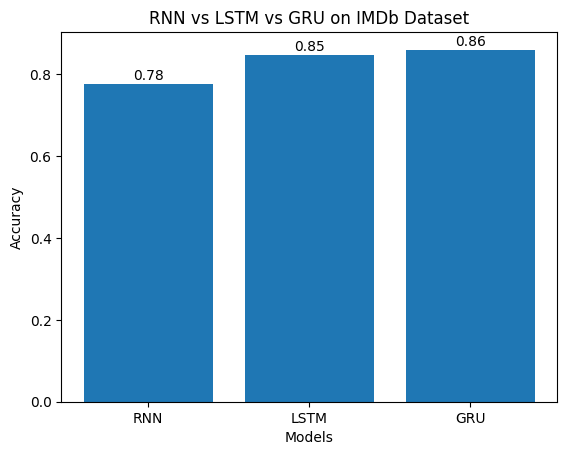

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

# -----------------------------
# 1. Load Dataset
# -----------------------------
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# -----------------------------
# 2. Model Builder Function
# -----------------------------
def build_model(model_type):
    model = Sequential()

    model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# -----------------------------
# 3. Train Models
# -----------------------------
models = ["RNN", "LSTM", "GRU"]
accuracies = []

for m in models:
    print(f"\nTraining {m}...")

    model = build_model(m)

    model.fit(
        x_train, y_train,
        epochs=3,           # increase to 5–10 for better accuracy
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{m} Accuracy: {acc:.4f}")

    accuracies.append(acc)

# -----------------------------
# 4. Plot Bar Graph
# -----------------------------
plt.figure()
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM vs GRU on IMDb Dataset")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()